# Does this workflow actually find the right features? — a validation notebook

This notebook exists to answer one question: **can the numbers in
`imerg_features_YYYYMM.csv` be trusted?**

It does that in three passes, each stricter than the last:

1. **Synthetic data with known answers.** We hand-build a field containing features whose
   size, mean, maximum and core counts we know exactly because we drew them. If the code
   reports anything other than the drawn values, it is wrong. This also pins down the
   behaviours that are easy to get silently wrong: the `-9999.9` fill value, the `min_size`
   cut, and the connectivity rule.
2. **A picture of real data.** One hour of IMERG, every detected feature drawn in its own
   colour with its ID, so the partition can be checked by eye against the precipitation
   field it came from.
3. **Independent re-derivation on that real data.** Every statistic is recomputed from the
   raw array with plain NumPy/SciPy — no `gridfeatures` — and compared value-by-value
   against what the production code produced. Agreement here is the real evidence: two
   independent implementations landing on identical numbers for ~1000 real features.

Everything runs against **the production code path**: the same loader
(`imerg_hdf5_io`) and the same statistics definitions (`imerg_features.build_statistics`)
that the PBS jobs use. Nothing is re-specified for the demo, so this notebook cannot
accidentally validate a different pipeline than the one that produces the CSVs.

> This is a light, inspection-sized job (one hour of data, a few seconds of compute), so it
> is fine to run interactively on the login node. Full months go through PBS.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib.patches import Rectangle
from scipy import ndimage

SCRIPTS = Path('/home1/pedro/Projects/imerg_precipitation_features/scripts')
sys.path.insert(0, str(SCRIPTS))

import gridfeatures as gf
from gridfeatures import stats
from gridfeatures.swath import swath_index, EARTH_RADIUS_KM as R
from gridfeatures.runner import _area_from_2d

# The production loader and the production statistics -- imported, not re-specified.
import imerg_hdf5_io as io
from imerg_features import build_statistics, swath_coords

print('gridfeatures', gf.__version__)
print('numpy', np.__version__, '| pandas', pd.__version__)

gridfeatures 0.3.0
numpy 2.5.1 | pandas 3.0.3


## 2. User parameters

Everything adjustable lives in this one cell. Re-run the notebook after changing anything
here; all downstream results, plots and checks follow from these values.

In [2]:
# ── what to load ────────────────────────────────────────────────────────────
ARCHIVE   = '/home1/pedro/Projects/imerg_precipitation_features/data/imerg_hhr'
YEAR      = 2022
MONTH     = 2
DAY       = 15
HOUR      = 18          # the one-hour period: the :00 and :30 granules of this hour
MODE      = 'hourly'    # 'hourly' = mean of the two granules; 'halfhour' = the :00 only

LON_CONVENTION = '0-360'   # production default; keeps swath seams where the CSVs have them

# ── detection ───────────────────────────────────────────────────────────────
THRESHOLD    = 1.0      # mm/hr; a pixel joins a feature if value > THRESHOLD
MIN_SIZE     = 5        # pixels; features smaller than this are discarded
CONNECTIVITY = 2        # 1 = 4-connected (edges), 2 = 8-connected (edges + corners)

CORE_LO, CORE_HI = 5.0, 10.0    # mm/hr core thresholds reported as px_ge_* / n_cores_*

# ── domain ──────────────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX = -20.0, 20.0  # detection band -- keep at production values

# Map window. Detection always runs on the full band above (exactly as production
# does); this only sets what the map zooms into. A smaller window means legible
# feature labels.
PLOT_LAT = (-12.0, 6.0)
PLOT_LON = (100.0, 135.0)       # 0-360 frame

# ── artificial swath ────────────────────────────────────────────────────────
SWATH_WIDTH_KM  = 245.0
SWATH_ANGLE_DEG = 65.0
ORIGIN_LAT, ORIGIN_LON = 0.0, 180.0

# ── plotting ────────────────────────────────────────────────────────────────
PRECIP_VMAX = 20.0      # mm/hr, colour ceiling for the background field
LABEL_MIN_PX = 25       # only label features at least this big, to avoid clutter

## 3. Synthetic data: features whose answers we already know

Before touching real data we check the code against a field we drew ourselves. The
advantage is that there is no ambiguity about the right answer — we can assert exact
equality rather than "looks plausible".

The test field contains five deliberate cases:

| # | what it is | why it is here |
|---|---|---|
| A | 4×5 solid block, 20 px, all 2 mm/hr | basic size / mean / max |
| B | 3×3 block, 9 px, with a 2-px core ≥ 10 mm/hr | core counting |
| C | two 3×3 blocks touching **only at a corner** | connectivity rule (8- vs 4-connected) |
| D | a 3-px blob | must be **dropped** by `MIN_SIZE = 5` |
| E | a block of raw `-9999.9` fill | must be treated as missing, never as precipitation |

Case E is the one worth dwelling on. IMERG stores missing data as `-9999.9`, not `NaN`.
If that sentinel survived into the field it would sit below the threshold and quietly
count as valid *dry* ground — which would corrupt the domain-edge accounting, because
`touches_domain_edge` is defined by adjacency to `NaN`.

In [3]:
# A small synthetic grid on a real 0.1-deg geographic footprint.
syn_nlat, syn_nlon = 40, 60
syn_lats = -2.0 + 0.1 * np.arange(syn_nlat)
syn_lons = 120.0 + 0.1 * np.arange(syn_nlon)
syn_lats2d, syn_lons2d = np.meshgrid(syn_lats, syn_lons, indexing='ij')

F = np.zeros((syn_nlat, syn_nlon))

# A: 4x5 = 20 px at a flat 2.0 mm/hr
F[5:9, 5:10] = 2.0
# B: 3x3 = 9 px at 3.0, with a 2-px core at 12.0
F[5:8, 20:23] = 3.0
F[6, 21:23] = 12.0
# C: two 3x3 blocks touching at a single corner
F[20:23, 10:13] = 4.0
F[23:26, 13:16] = 4.0
# D: 3 px -- below MIN_SIZE
F[30:31, 30:33] = 6.0
# E: a block of raw IMERG fill value
F[15:20, 40:45] = -9999.9

expected = {
    'A_size': 20, 'A_mean': 2.0, 'A_max': 2.0,
    'B_size': 9,  'B_core_hi_px': 2,
    'C_size_8conn': 18,  'C_size_4conn': 9,
    'D_size': 3,
}
print('drawn:', expected)
print('raw fill present in field:', bool((F <= -9000).any()))

drawn: {'A_size': 20, 'A_mean': 2.0, 'A_max': 2.0, 'B_size': 9, 'B_core_hi_px': 2, 'C_size_8conn': 18, 'C_size_4conn': 9, 'D_size': 3}
raw fill present in field: True


### 3.1 The fill value must become `NaN` on load

`imerg_hdf5_io` does this conversion during the read. We apply the same rule here and
confirm the sentinel is gone — and, critically, that it did **not** turn into a low
precipitation value.

In [4]:
F_loaded = F.copy()
F_loaded[F_loaded <= io.MISSING_BELOW] = np.nan   # the production rule

checks = []
checks.append(('fill sentinel is gone from the field',
               not bool((F_loaded <= -9000).any())))
checks.append(('fill became NaN (25 px), not a number',
               int(np.isnan(F_loaded).sum()) == 25))
checks.append(('fill did NOT become valid weak precip',
               not bool(np.nansum(F_loaded[15:20, 40:45]) > 0)))

for name, ok in checks:
    print(f"  {'PASS' if ok else 'FAIL':4s}  {name}")

  PASS  fill sentinel is gone from the field
  PASS  fill became NaN (25 px), not a number
  PASS  fill did NOT become valid weak precip


### 3.2 Sizes, means, maxima and cores are exactly what we drew

In [5]:
def run_extraction(field, lats2d, lons2d, threshold, min_size, connectivity,
                   width_km=SWATH_WIDTH_KM, angle=SWATH_ANGLE_DEG,
                   origin=(ORIGIN_LAT, ORIGIN_LON)):
    # Runs the PRODUCTION extraction (production Config + production statistics).
    area = _area_from_2d(lats2d, lons2d)
    swath = swath_index(lats2d, lons2d, width_km, angle, origin=origin)
    along2d, perp2d = swath_coords(lats2d, lons2d, angle, origin)
    config = gf.Config(
        files='synthetic', variable='precipitation',
        threshold=threshold, min_size=min_size,
        comparison='>', connectivity=connectivity,
        use_swath=True, swath_width_km=width_km, swath_angle_deg=angle,
        statistics=build_statistics(perp2d, along2d, width_km, connectivity),
    )
    feats = gf.extract_features(field, lats2d, lons2d, config, source='synthetic',
                                time='synthetic', time_index=0, area=area, swath=swath)
    return pd.DataFrame([gf.feature_row(f, config) for f in feats]), feats


syn_df, syn_feats = run_extraction(F_loaded, syn_lats2d, syn_lons2d,
                                   THRESHOLD, MIN_SIZE, CONNECTIVITY)
syn_df = syn_df.sort_values('size_px', ascending=False).reset_index(drop=True)
syn_df[['size_px', 'mean_precip_mm_hr', 'max_precip_mm_hr',
        'px_ge_5mmhr', 'px_ge_10mmhr', 'n_cores_10mmhr']]

,size_px,mean_precip_mm_hr,max_precip_mm_hr,px_ge_5mmhr,px_ge_10mmhr,n_cores_10mmhr
0,20,2.0,2.0,0,0,0
1,18,4.0,4.0,0,0,0
2,9,5.0,12.0,2,2,1


In [6]:
sizes = sorted(syn_df.size_px.tolist())
A = syn_df[np.isclose(syn_df.max_precip_mm_hr, 2.0)].iloc[0]
B = syn_df[np.isclose(syn_df.max_precip_mm_hr, 12.0)].iloc[0]
Cc = syn_df[np.isclose(syn_df.max_precip_mm_hr, 4.0)].iloc[0]

syn_checks = [
    ('feature D (3 px) dropped by MIN_SIZE=5', 3 not in sizes),
    ('exactly 3 features survive',             len(syn_df) == 3),
    ('A size == 20 px as drawn',               int(A.size_px) == expected['A_size']),
    ('A mean == 2.0 mm/hr exactly',            np.isclose(A.mean_precip_mm_hr, 2.0)),
    ('A max  == 2.0 mm/hr exactly',            np.isclose(A.max_precip_mm_hr, 2.0)),
    ('B size == 9 px as drawn',                int(B.size_px) == expected['B_size']),
    ('B core >=10 mm/hr == 2 px',              int(B.px_ge_10mmhr) == expected['B_core_hi_px']),
    ('B has exactly 1 contiguous hi core',     int(B.n_cores_10mmhr) == 1),
    ('C corner-touching merged (8-conn)',      int(Cc.size_px) == expected['C_size_8conn']),
    ('no feature overlaps the NaN block',      not bool(syn_df.size_px.isna().any())),
]
for name, ok in syn_checks:
    print(f"  {'PASS' if ok else 'FAIL':4s}  {name}")
assert all(ok for _, ok in syn_checks), 'SYNTHETIC CHECK FAILED'
print('\nAll synthetic checks passed.')

  PASS  feature D (3 px) dropped by MIN_SIZE=5
  PASS  exactly 3 features survive
  PASS  A size == 20 px as drawn
  PASS  A mean == 2.0 mm/hr exactly
  PASS  A max  == 2.0 mm/hr exactly
  PASS  B size == 9 px as drawn
  PASS  B core >=10 mm/hr == 2 px
  PASS  B has exactly 1 contiguous hi core
  PASS  C corner-touching merged (8-conn)
  PASS  no feature overlaps the NaN block

All synthetic checks passed.


### 3.3 The connectivity switch does what it claims

Case C is two blocks meeting at a single corner. Under 8-connectivity they are one
feature of 18 px; under 4-connectivity they are two features of 9 px each. This is worth
demonstrating explicitly because it is a real scientific choice — it decides whether two
barely-touching cells are one storm or two — and production runs with `connectivity=2`.

In [7]:
df8, _ = run_extraction(F_loaded, syn_lats2d, syn_lons2d, THRESHOLD, MIN_SIZE, 2)
df4, _ = run_extraction(F_loaded, syn_lats2d, syn_lons2d, THRESHOLD, MIN_SIZE, 1)

c8 = sorted(df8[np.isclose(df8.max_precip_mm_hr, 4.0)].size_px.tolist())
c4 = sorted(df4[np.isclose(df4.max_precip_mm_hr, 4.0)].size_px.tolist())
print(f'8-connected: {len(c8)} feature(s), sizes {c8}')
print(f'4-connected: {len(c4)} feature(s), sizes {c4}')

conn_checks = [
    ('8-conn merges the corner touch into 18 px', c8 == [18]),
    ('4-conn splits it into two 9 px features',   c4 == [9, 9]),
]
for name, ok in conn_checks:
    print(f"  {'PASS' if ok else 'FAIL':4s}  {name}")
assert all(ok for _, ok in conn_checks)

8-connected: 1 feature(s), sizes [18]
4-connected: 2 feature(s), sizes [9, 9]
  PASS  8-conn merges the corner touch into 18 px
  PASS  4-conn splits it into two 9 px features


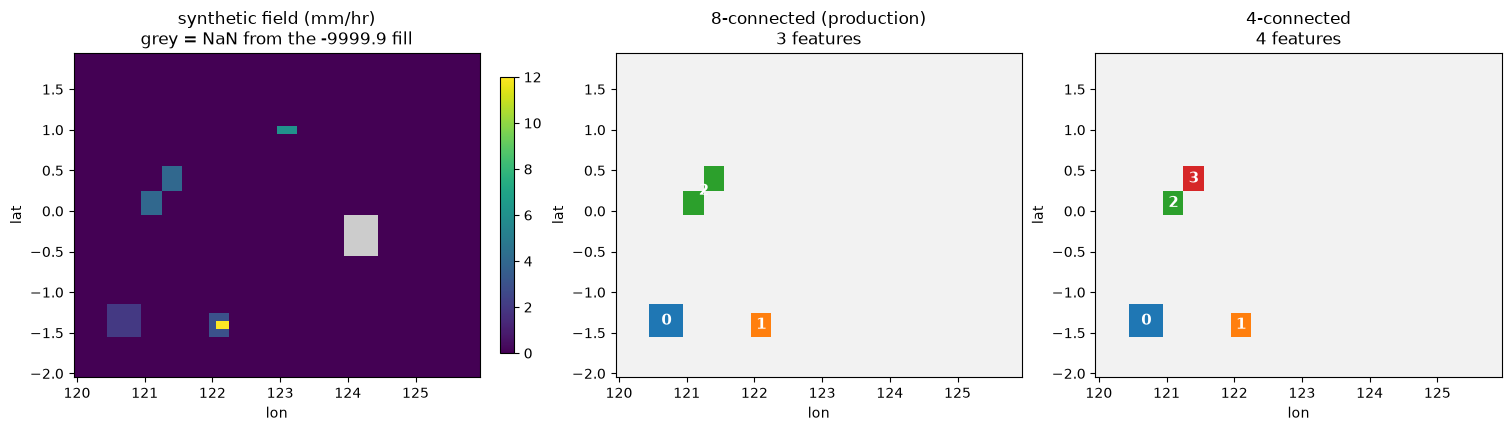

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)

show = np.where(np.isnan(F_loaded), np.nan, F_loaded)
ax = axes[0]
im = ax.pcolormesh(syn_lons, syn_lats, show, cmap='viridis', shading='nearest')
ax.set_title('synthetic field (mm/hr)\ngrey = NaN from the -9999.9 fill')
ax.set_facecolor('0.8')
fig.colorbar(im, ax=ax, shrink=0.85)

for ax, df, conn in ((axes[1], df8, '8-connected (production)'),
                     (axes[2], df4, '4-connected')):
    lab = np.full(F_loaded.shape, np.nan)
    _, fts = run_extraction(F_loaded, syn_lats2d, syn_lons2d, THRESHOLD, MIN_SIZE,
                            2 if '8' in conn else 1)
    for k, f in enumerate(fts):
        lab[f.rows, f.cols] = k
    ax.pcolormesh(syn_lons, syn_lats, lab, cmap='tab10', shading='nearest',
                  vmin=0, vmax=9)
    ax.set_facecolor('0.95')
    ax.set_title(f'{conn}\n{len(fts)} features')
    for k, f in enumerate(fts):
        ax.text(syn_lons[f.cols].mean(), syn_lats[f.rows].mean(), str(k),
                ha='center', va='center', fontsize=11, fontweight='bold', color='w')

for ax in axes:
    ax.set_xlabel('lon'); ax.set_ylabel('lat')
plt.show()

## 4. Real data: one hour of IMERG

Now the same code on real granules, loaded through the production loader. Note the load
returns **mm/hr already** — IMERG V07 stores a rate, so there is no unit conversion to get
wrong, and `THRESHOLD` means the same thing whether we average two granules or use one.

In [9]:
import datetime as dt

index = io.scan_archive(ARCHIVE, YEAR, MONTH)
steps = io.build_timesteps(index, YEAR, MONTH, MODE)

target = dt.datetime(YEAR, MONTH, DAY, HOUR).isoformat()
step_i = next(i for i, (t, _) in enumerate(steps) if t == target)
tlabel, paths = steps[step_i]

print(f'{MODE}: {len(steps)} timesteps this month; using index {step_i} = {tlabel}')
for p in paths:
    print('   ', Path(p).name)

lats_all, lons, roll = io.read_grid(paths[0], LON_CONVENTION)
idx = np.where((lats_all >= LAT_MIN) & (lats_all <= LAT_MAX))[0]
lat_slice = slice(int(idx[0]), int(idx[-1]) + 1)
lats = lats_all[lat_slice]

field = io.load_field(paths, lat_slice, roll)
lats2d, lons2d = np.meshgrid(lats, lons, indexing='ij')

print(f'\nfield {field.shape}  lat {lats[0]:.2f}..{lats[-1]:.2f}  '
      f'lon {lons[0]:.2f}..{lons[-1]:.2f} ({LON_CONVENTION})')
print(f'range {np.nanmin(field):.2f} .. {np.nanmax(field):.2f} mm/hr  '
      f'| NaN {int(np.isnan(field).sum())}  | raw fill left: {int((field <= -9000).sum())}')

hourly: 672 timesteps this month; using index 354 = 2022-02-15T18:00:00
    3B-HHR.MS.MRG.3IMERG.20220215-S180000-E182959.1080.V07B.HDF5
    3B-HHR.MS.MRG.3IMERG.20220215-S183000-E185959.1110.V07B.HDF5



field (400, 3600)  lat -19.95..19.95  lon 0.05..359.95 (0-360)
range 0.00 .. 49.33 mm/hr  | NaN 0  | raw fill left: 0


### 4.1 Averaging two granules is an average of *rates*

A quick sanity check on the `hourly` mode: because the data are rates, the hour is the
plain mean of the two half-hours — not a sum. If the code were treating these as
accumulations, the hourly field would come out roughly twice as large and every threshold
in the study would silently mean something different.

In [10]:
if MODE == 'hourly':
    g0 = io.load_field([paths[0]], lat_slice, roll)
    g1 = io.load_field([paths[1]], lat_slice, roll)
    manual = (g0 + g1) / 2.0
    same = np.allclose(field, manual, equal_nan=True)
    print(f'  mean rate of the two granules reproduces the loaded field : {same}')
    print(f'  granule :00 mean {np.nanmean(g0):.4f} | :30 mean {np.nanmean(g1):.4f} '
          f'| hour {np.nanmean(field):.4f} mm/hr')
    print(f'  hour mean lies between the two granule means             : '
          f'{min(np.nanmean(g0), np.nanmean(g1)) <= np.nanmean(field) <= max(np.nanmean(g0), np.nanmean(g1))}')
    assert same
else:
    print('MODE is halfhour -- single granule, nothing to average.')

  mean rate of the two granules reproduces the loaded field : True
  granule :00 mean 0.1951 | :30 mean 0.1960 | hour 0.1955 mm/hr
  hour mean lies between the two granule means             : True


### 4.2 Run the production extraction

In [11]:
area = _area_from_2d(lats2d, lons2d)
swath = swath_index(lats2d, lons2d, SWATH_WIDTH_KM, SWATH_ANGLE_DEG,
                    origin=(ORIGIN_LAT, ORIGIN_LON))
along2d, perp2d = swath_coords(lats2d, lons2d, SWATH_ANGLE_DEG, (ORIGIN_LAT, ORIGIN_LON))

config = gf.Config(
    files='demo', variable='precipitation',
    threshold=THRESHOLD, min_size=MIN_SIZE,
    comparison='>', connectivity=CONNECTIVITY,
    use_swath=True, swath_width_km=SWATH_WIDTH_KM, swath_angle_deg=SWATH_ANGLE_DEG,
    statistics=build_statistics(perp2d, along2d, SWATH_WIDTH_KM, CONNECTIVITY),
)

feats = gf.extract_features(field, lats2d, lons2d, config, source=Path(paths[0]).name,
                            time=tlabel, time_index=step_i, area=area, swath=swath)
df = pd.DataFrame([gf.feature_row(f, config) for f in feats])
df['local_id'] = np.arange(len(df))

print(f'{len(df)} features over the full {LAT_MIN:g}..{LAT_MAX:g} band at {tlabel}')
df.head()

867 features over the full -20..20 band at 2022-02-15T18:00:00


,source_file,feature_id,time,time_index,swath_id,px_in_swath,n_swaths,crosses_swath_boundary,size_px,area_km2,...,largest_core_10mmhr_px,cross_swath_extent_km,along_swath_extent_km,fits_in_swath,swath_edge_px,swath_edge_px_in_dominant,swath_edge_frac_in_dominant,domain_edge_px,touches_domain_edge,local_id
0,3B-HHR.MS.MRG.3IMERG.20220215-S180000-E182959....,3B-HHR.MS.MRG.3IMERG.20220215-S180000-E182959....,2022-02-15T18:00:00,354,141,9,1,False,9,1046.589909,...,0,49.709240,29.553843,True,0,0,0.000000,4,True,0
1,3B-HHR.MS.MRG.3IMERG.20220215-S180000-E182959....,3B-HHR.MS.MRG.3IMERG.20220215-S180000-E182959....,2022-02-15T18:00:00,354,128,25,1,False,25,2911.911608,...,0,108.817118,51.746390,True,0,0,0.000000,3,True,1
2,3B-HHR.MS.MRG.3IMERG.20220215-S180000-E182959....,3B-HHR.MS.MRG.3IMERG.20220215-S180000-E182959....,2022-02-15T18:00:00,354,128,16,1,False,16,1862.636623,...,0,64.486370,50.388414,True,2,2,0.125000,2,True,2
3,3B-HHR.MS.MRG.3IMERG.20220215-S180000-E182959....,3B-HHR.MS.MRG.3IMERG.20220215-S180000-E182959....,2022-02-15T18:00:00,354,86,82,2,True,101,11776.147063,...,0,178.681313,116.911754,True,11,6,0.073171,9,True,3
4,3B-HHR.MS.MRG.3IMERG.20220215-S180000-E182959....,3B-HHR.MS.MRG.3IMERG.20220215-S180000-E182959....,2022-02-15T18:00:00,354,66,755,4,True,1668,196534.938754,...,30,800.837182,830.173196,False,145,53,0.070199,37,True,4


## 5. The map

Each detected feature gets its own colour and, if it is big enough to label legibly, its
`local_id` printed at its centroid. The left panel is the precipitation field the features
were derived from; the right panel is the resulting partition. Reading them together is
the eyeball check: every coloured blob on the right should correspond to a coherent patch
of precipitation on the left, and nothing above the threshold should be left uncoloured
except features below `MIN_SIZE`.

76 features have their centroid inside the map window


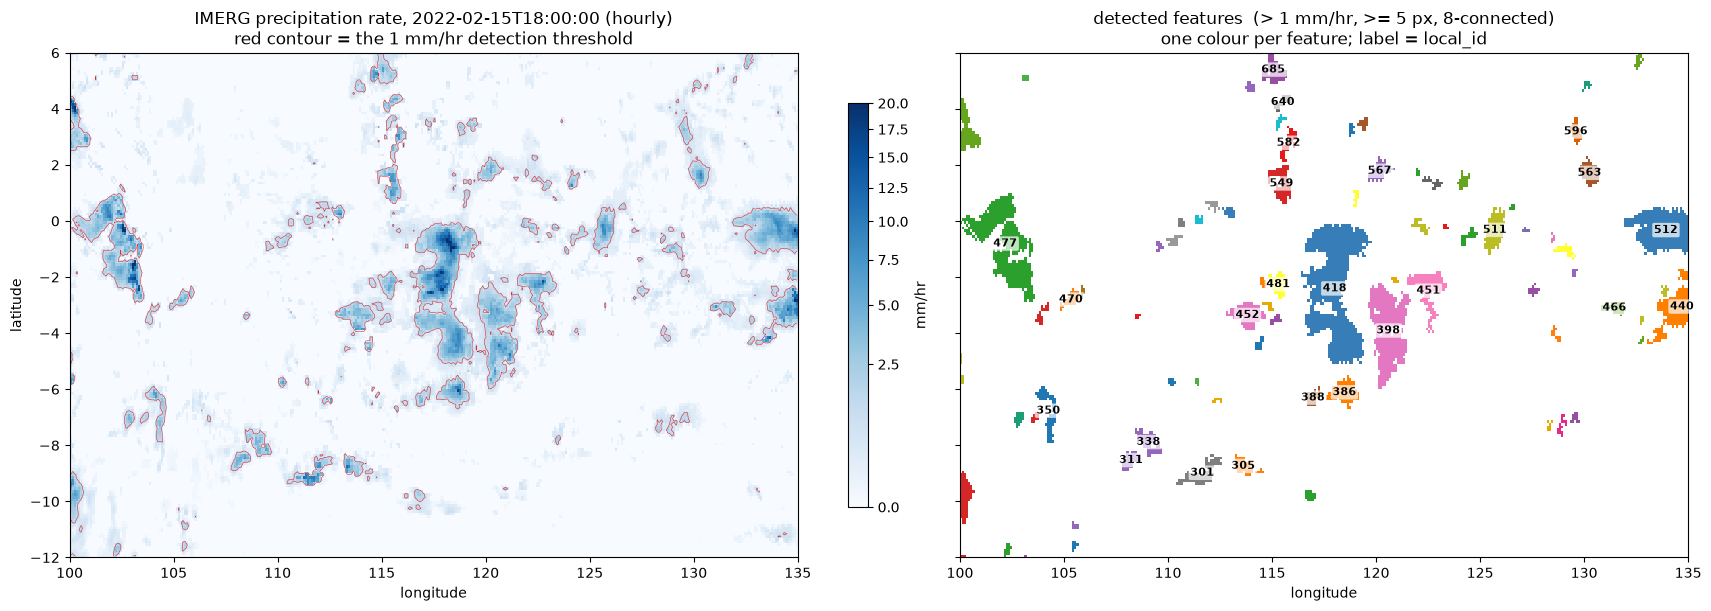

In [12]:
r0, r1 = np.searchsorted(lats, PLOT_LAT)
c0, c1 = np.searchsorted(lons, PLOT_LON)

# feature -> label image, restricted to the window
labels = np.full(field.shape, np.nan)
for _, f in enumerate(feats):
    labels[f.rows, f.cols] = df.local_id.iloc[_]

win_field = field[r0:r1, c0:c1]
win_labels = labels[r0:r1, c0:c1]
win_lats, win_lons = lats[r0:r1], lons[c0:c1]

in_window = df[(df.centroid_lat.between(*PLOT_LAT)) & (df.centroid_lon.between(*PLOT_LON))]
print(f'{len(in_window)} features have their centroid inside the map window')

fig, axes = plt.subplots(1, 2, figsize=(17, 6), constrained_layout=True, sharey=True)

ax = axes[0]
# Gamma stretch: most tropical rain rates are small, so a linear scale renders
# the field almost blank. This only affects display, never the detection.
im = ax.pcolormesh(win_lons, win_lats, win_field, cmap='Blues', shading='nearest',
                   norm=mcolors.PowerNorm(0.5, vmin=0, vmax=PRECIP_VMAX))
# The detection boundary, drawn on the field itself: everything inside a contour
# is what the threshold selects, so the two panels can be compared directly.
ax.contour(win_lons, win_lats, np.nan_to_num(win_field), levels=[THRESHOLD],
           colors='#d62728', linewidths=0.4)
ax.set_facecolor('white')
ax.set_title(f'IMERG precipitation rate, {tlabel} ({MODE})\n'
             f'red contour = the {THRESHOLD:g} mm/hr detection threshold')
fig.colorbar(im, ax=ax, shrink=0.8, label='mm/hr')

# Saturated, stably-shuffled colours so adjacent features stay distinguishable
# and nothing fades into the background.
base = np.vstack([plt.get_cmap('tab10').colors,
                  plt.get_cmap('Dark2').colors,
                  plt.get_cmap('Set1').colors])
rng = np.random.default_rng(0)
cmap = mcolors.ListedColormap(base[rng.permutation(len(base))][np.arange(256) % len(base)])

ax = axes[1]
ax.pcolormesh(win_lons, win_lats, win_labels % 256, cmap=cmap, shading='nearest',
              vmin=0, vmax=255)
ax.set_facecolor('white')
ax.set_title(f'detected features  (> {THRESHOLD:g} mm/hr, >= {MIN_SIZE} px, '
             f'{CONNECTIVITY*4}-connected)\n'
             f'one colour per feature; label = local_id')

for _, row in in_window.iterrows():
    if row.size_px >= LABEL_MIN_PX:
        ax.text(row.centroid_lon, row.centroid_lat, str(int(row.local_id)),
                ha='center', va='center', fontsize=8, fontweight='bold',
                color='k', bbox=dict(boxstyle='round,pad=0.15', fc='w', ec='none', alpha=0.7))

for ax in axes:
    ax.set_xlabel('longitude'); ax.set_xlim(PLOT_LON); ax.set_ylim(PLOT_LAT)
axes[0].set_ylabel('latitude')
plt.show()

### 5.1 One feature up close

Zooming to a single feature makes the pixel-level accounting checkable by hand: the
outlined cells are its members, and the hatched cells are the ones counted in
`px_ge_5mmhr`. The printed row is what lands in the CSV.

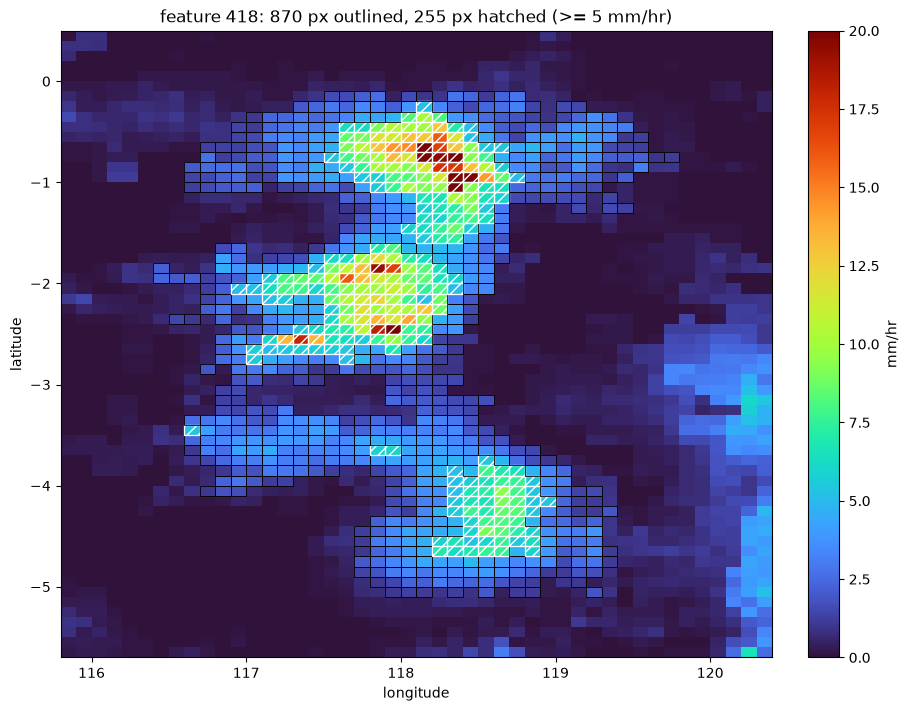

size_px                                  870
area_km2                       107439.141854
centroid_lat                       -2.406159
centroid_lon                      118.014468
max_precip_mm_hr                   26.559999
mean_precip_mm_hr                   4.560494
px_ge_5mmhr                              255
px_ge_10mmhr                              67
n_cores_5mmhr                              5
cross_swath_extent_km             459.390984
swath_id                                 102
px_in_swath                              480
swath_edge_px_in_dominant                 43
swath_edge_frac_in_dominant         0.089583
Name: 418, dtype: object

In [13]:
pick = in_window.sort_values('size_px', ascending=False).iloc[0]
pf = feats[int(pick.local_id)]

pad = 6
rr0, rr1 = max(pf.rows.min() - pad, 0), min(pf.rows.max() + pad + 1, field.shape[0])
cc0, cc1 = max(pf.cols.min() - pad, 0), min(pf.cols.max() + pad + 1, field.shape[1])
sub = field[rr0:rr1, cc0:cc1]
mask = np.zeros(field.shape, bool); mask[pf.rows, pf.cols] = True
submask = mask[rr0:rr1, cc0:cc1]

fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
im = ax.pcolormesh(lons[cc0:cc1], lats[rr0:rr1], sub, cmap='turbo',
                   shading='nearest', vmin=0, vmax=PRECIP_VMAX)
fig.colorbar(im, ax=ax, label='mm/hr')

dlon = lons[1] - lons[0]; dlat = lats[1] - lats[0]
for r, c in zip(*np.where(submask)):
    ax.add_patch(Rectangle((lons[cc0 + c] - dlon / 2, lats[rr0 + r] - dlat / 2),
                           dlon, dlat, fill=False, ec='k', lw=0.6))
    if sub[r, c] >= CORE_LO:
        ax.add_patch(Rectangle((lons[cc0 + c] - dlon / 2, lats[rr0 + r] - dlat / 2),
                               dlon, dlat, fill=False, ec='w', lw=0.9, hatch='///'))

ax.set_title(f'feature {int(pick.local_id)}: {int(pick.size_px)} px outlined, '
             f'{int(pick.px_ge_5mmhr)} px hatched (>= {CORE_LO:g} mm/hr)')
ax.set_xlabel('longitude'); ax.set_ylabel('latitude')
plt.show()

pick[['size_px', 'area_km2', 'centroid_lat', 'centroid_lon', 'max_precip_mm_hr',
      'mean_precip_mm_hr', 'px_ge_5mmhr', 'px_ge_10mmhr', 'n_cores_5mmhr',
      'cross_swath_extent_km', 'swath_id', 'px_in_swath',
      'swath_edge_px_in_dominant', 'swath_edge_frac_in_dominant']]

## 6. Independent re-derivation

This is the section that carries the weight. Everything below is computed from `field`
with plain NumPy and SciPy — `gridfeatures` is not used — and then compared against the
production output for **every** feature.

### 6.1 Does an independent labelling find the same features?

We re-run connected components ourselves and compare the resulting partition to
`gridfeatures`' as a set of pixel sets. This is stricter than comparing counts: it
requires the two implementations to agree on exactly which pixels belong to which feature.

In [14]:
structure = ndimage.generate_binary_structure(2, CONNECTIVITY)
binary = (field > THRESHOLD) & ~np.isnan(field)
lab_mine, n_mine = ndimage.label(binary, structure=structure)

sizes_mine = ndimage.sum_labels(np.ones_like(lab_mine), lab_mine,
                                index=np.arange(1, n_mine + 1))
keep = np.where(sizes_mine >= MIN_SIZE)[0] + 1
print(f'independent labelling : {n_mine} raw components, {len(keep)} with >= {MIN_SIZE} px')
print(f'gridfeatures          : {len(feats)} features')

mine = {frozenset(map(tuple, np.argwhere(lab_mine == k))) for k in keep}
theirs = {frozenset(zip(f.rows.tolist(), f.cols.tolist())) for f in feats}

part_checks = [
    ('same number of features',            len(mine) == len(theirs)),
    ('identical pixel partition',          mine == theirs),
    ('no feature smaller than MIN_SIZE',   min(len(s) for s in theirs) >= MIN_SIZE),
    ('no NaN pixel inside any feature',
        not any(np.isnan(field[tuple(np.array(list(s)).T)]).any() for s in theirs)),
]
for name, ok in part_checks:
    print(f"  {'PASS' if ok else 'FAIL':4s}  {name}")
assert all(ok for _, ok in part_checks), 'PARTITION MISMATCH'

independent labelling : 2183 raw components, 867 with >= 5 px
gridfeatures          : 867 features


  PASS  same number of features
  PASS  identical pixel partition
  PASS  no feature smaller than MIN_SIZE
  PASS  no NaN pixel inside any feature


### 6.2 Recompute every statistic from scratch

For each feature we recompute size, mean, max, total, core pixel counts, core component
counts, the geographic centroid and the cross-swath extent directly from the arrays, then
compare against the production values.

Cell areas need care. A lat/lon cell is a spherical quadrilateral, and its exact area is

$$A = R^2\,\lvert\sin\varphi_2 - \sin\varphi_1\rvert\,\Delta\lambda$$

between the cell's **edges**, not the small-angle approximation
$A \approx R^2\cos\varphi\,\Delta\varphi\,\Delta\lambda$ evaluated at the cell centre. The
two differ by about 1 part in 10⁴ at 0.1° resolution — invisible in a single cell, but it
propagates into `area_km2`, `total_precip_mm_hr_km2` and the area-weighted centroids.
We use the exact form below, and check the size of the discrepancy explicitly in §6.2.1
so the choice is visible rather than buried.

In [15]:
def exact_cell_areas(lats_1d, lons_1d):
    # Independent implementation of the spherical cell area, from edges.
    def edges(c):
        mid = 0.5 * (c[1:] + c[:-1])
        return np.concatenate([[c[0] - (mid[0] - c[0])], mid, [c[-1] + (c[-1] - mid[-1])]])
    lat_e = np.radians(edges(lats_1d))
    lon_e = np.radians(edges(lons_1d))
    dsin = np.abs(np.sin(lat_e[1:]) - np.sin(lat_e[:-1]))
    dlon = np.abs(np.diff(lon_e))
    return (R ** 2) * np.outer(dsin, dlon)


area_mine = exact_cell_areas(lats, lons)
print('independent area grid:', area_mine.shape)
print('matches production _area_from_2d :',
      bool(np.allclose(area_mine, area, rtol=0, atol=1e-9)))

recomputed = []
for f in feats:
    rows, cols = f.rows, f.cols
    vals = field[rows, cols]
    cell_area = area_mine[rows, cols]

    core_lo = vals >= CORE_LO
    core_hi = vals >= CORE_HI

    # contiguous cores, counted with an independent labelling of the core mask
    m = np.zeros(field.shape, bool); m[rows, cols] = True
    core_mask = m & (field >= CORE_LO) & ~np.isnan(field)
    _, n_core_lo = ndimage.label(core_mask, structure=structure)

    recomputed.append(dict(
        size_px=len(rows),
        area_km2=cell_area.sum(),
        max_precip_mm_hr=vals.max(),
        mean_precip_mm_hr=vals.mean(),
        total_precip_mm_hr_km2=(vals * cell_area).sum(),
        centroid_lat=(lats[rows] * cell_area).sum() / cell_area.sum(),
        centroid_lon=(lons[cols] * cell_area).sum() / cell_area.sum(),
        px_ge_5mmhr=int(core_lo.sum()),
        px_ge_10mmhr=int(core_hi.sum()),
        n_cores_5mmhr=int(n_core_lo),
        cross_swath_extent_km=np.ptp(perp2d[rows, cols]),
        along_swath_extent_km=np.ptp(along2d[rows, cols]),
    ))

mine_df = pd.DataFrame(recomputed)
print(f'recomputed {len(mine_df)} features independently')
mine_df.head()

independent area grid: (400, 3600)
matches production _area_from_2d : True


recomputed 867 features independently


,size_px,area_km2,max_precip_mm_hr,mean_precip_mm_hr,total_precip_mm_hr_km2,centroid_lat,centroid_lon,px_ge_5mmhr,px_ge_10mmhr,n_cores_5mmhr,cross_swath_extent_km,along_swath_extent_km
0,9,1046.589909,1.365,1.197778,1253.543880,-19.861062,15.349978,0,0,0,49.709240,29.553843
1,25,2911.911608,7.930,2.881600,8387.713826,-19.601759,47.797750,1,0,1,108.817118,51.746390
2,16,1862.636623,6.395,2.571562,4787.590617,-19.687351,48.543717,3,0,1,64.486370,50.388414
3,101,11776.147063,8.750,2.732277,32152.501286,-19.434399,150.698083,11,0,1,178.681313,116.911754
4,1668,196534.938754,23.030,4.067227,798321.654339,-17.560994,199.155884,423,76,15,800.837182,830.173196


#### 6.2.1 Why the exact cell area, and not the cosine approximation

This check is here because writing this notebook actually caught it: the first version of
the independent recomputation used the small-angle approximation and disagreed with
production by ~5.7 km² on a ~20,000 km² feature. The production code was right and the
check was wrong — but a 10⁻⁴ disagreement is exactly the kind of thing that gets waved
through as floating-point noise, so it is worth showing what it really is.

In [16]:
lat_c = np.radians(lats)
dlat_rad = np.radians(abs(lats[1] - lats[0]))
dlon_rad = np.radians(abs(lons[1] - lons[0]))
area_approx = (R ** 2) * dlon_rad * dlat_rad * np.cos(lat_c)[:, None] * np.ones(lons.size)

rel = np.abs(area_approx - area_mine) / area_mine
print(f'cosine approximation vs exact spherical cell area:')
print(f'  relative error : {rel.min():.2e} .. {rel.max():.2e}  (median {np.median(rel):.2e})')
print(f'  worst cell     : {np.abs(area_approx - area_mine).max():.4f} km^2')

big = df.area_km2.max()
print(f'\n  on the largest feature here ({big:,.0f} km^2) that is a '
      f'~{big * np.median(rel):,.1f} km^2 error')
print('  -> production uses the exact form; so does the check below.')

cosine approximation vs exact spherical cell area:
  relative error : 2.21e-08 .. 8.00e-05  (median 8.52e-06)
  worst cell     : 0.0098 km^2

  on the largest feature here (371,697 km^2) that is a ~3.2 km^2 error
  -> production uses the exact form; so does the check below.


In [17]:
comparisons = [
    ('size_px',                 0),
    ('area_km2',                1e-6),
    ('max_precip_mm_hr',        1e-9),
    ('mean_precip_mm_hr',       1e-9),
    ('total_precip_mm_hr_km2',  1e-6),
    ('centroid_lat',            1e-9),
    ('centroid_lon',            1e-9),
    ('px_ge_5mmhr',             0),
    ('px_ge_10mmhr',            0),
    ('n_cores_5mmhr',           0),
    ('cross_swath_extent_km',   1e-9),
    ('along_swath_extent_km',   1e-9),
]

print(f'{"statistic":26s} {"max abs difference":>20s}   verdict')
print('-' * 62)
stat_checks = []
for col, tol in comparisons:
    diff = np.abs(mine_df[col].values - df[col].values)
    worst = float(diff.max())
    ok = worst <= tol if tol else bool((diff == 0).all())
    stat_checks.append((f'{col} matches independent recomputation', ok))
    print(f'{col:26s} {worst:20.3e}   {"PASS" if ok else "FAIL"}')

assert all(ok for _, ok in stat_checks), 'STATISTIC MISMATCH'
print(f'\nAll {len(comparisons)} statistics reproduced independently for '
      f'all {len(df)} features.')

statistic                    max abs difference   verdict
--------------------------------------------------------------
size_px                               0.000e+00   PASS
area_km2                              0.000e+00   PASS
max_precip_mm_hr                      0.000e+00   PASS
mean_precip_mm_hr                     0.000e+00   PASS
total_precip_mm_hr_km2                0.000e+00   PASS
centroid_lat                          0.000e+00   PASS
centroid_lon                          0.000e+00   PASS
px_ge_5mmhr                           0.000e+00   PASS
px_ge_10mmhr                          0.000e+00   PASS
n_cores_5mmhr                         0.000e+00   PASS
cross_swath_extent_km                 0.000e+00   PASS
along_swath_extent_km                 0.000e+00   PASS

All 12 statistics reproduced independently for all 867 features.


### 6.3 The swath accounting

The swath never selects features — it only annotates them — so these checks are about
internal consistency of the annotation. `px_in_swath` is the part of the feature inside
its **dominant** strip (what a single overpass would actually observe), and
`swath_edge_frac_in_dominant` is the share of that observed part sitting against a seam.
The `< 0.05` cut used in the DYAMOND comparison is applied to this column, so it is worth
confirming it behaves.

In [18]:
dom_px, dom_id_ok = [], []
for f in feats:
    ids, counts = np.unique(swath[f.rows, f.cols], return_counts=True)
    dom_px.append(int(counts.max()))
    dom_id_ok.append(int(ids[np.argmax(counts)]))
dom_px = np.array(dom_px)

swath_checks = [
    ('px_in_swath == size of the largest strip overlap',
        bool((df.px_in_swath.values == dom_px).all())),
    ('swath_id == the dominant strip id',
        bool((df.swath_id.values == np.array(dom_id_ok)).all())),
    ('px_in_swath <= size_px',
        bool((df.px_in_swath <= df.size_px).all())),
    ('n_swaths == 1  <=>  px_in_swath == size_px',
        bool(((df.n_swaths == 1) == (df.px_in_swath == df.size_px)).all())),
    ('crosses_swath_boundary <=> n_swaths > 1',
        bool((df.crosses_swath_boundary == (df.n_swaths > 1)).all())),
    ('edge_in_dominant <= px_in_swath',
        bool((df.swath_edge_px_in_dominant <= df.px_in_swath).all())),
    ('edge_in_dominant <= whole-feature swath_edge_px',
        bool((df.swath_edge_px_in_dominant <= df.swath_edge_px).all())),
    ('frac == edge_in_dominant / px_in_swath',
        bool((np.abs(df.swath_edge_frac_in_dominant
                     - df.swath_edge_px_in_dominant / df.px_in_swath) < 1e-9).all())),
    ('frac within [0, 1]',
        bool(df.swath_edge_frac_in_dominant.between(0, 1).all())),
    ('fits_in_swath <=> cross-swath extent <= width',
        bool((df.fits_in_swath == (df.cross_swath_extent_km <= SWATH_WIDTH_KM)).all())),
    ('single-strip features always fit',
        bool((~(df.n_swaths == 1) | df.fits_in_swath).all())),
]
for name, ok in swath_checks:
    print(f"  {'PASS' if ok else 'FAIL':4s}  {name}")
assert all(ok for _, ok in swath_checks), 'SWATH CHECK FAILED'

  PASS  px_in_swath == size of the largest strip overlap
  PASS  swath_id == the dominant strip id
  PASS  px_in_swath <= size_px
  PASS  n_swaths == 1  <=>  px_in_swath == size_px
  PASS  crosses_swath_boundary <=> n_swaths > 1
  PASS  edge_in_dominant <= px_in_swath
  PASS  edge_in_dominant <= whole-feature swath_edge_px
  PASS  frac == edge_in_dominant / px_in_swath
  PASS  frac within [0, 1]
  PASS  fits_in_swath <=> cross-swath extent <= width
  PASS  single-strip features always fit


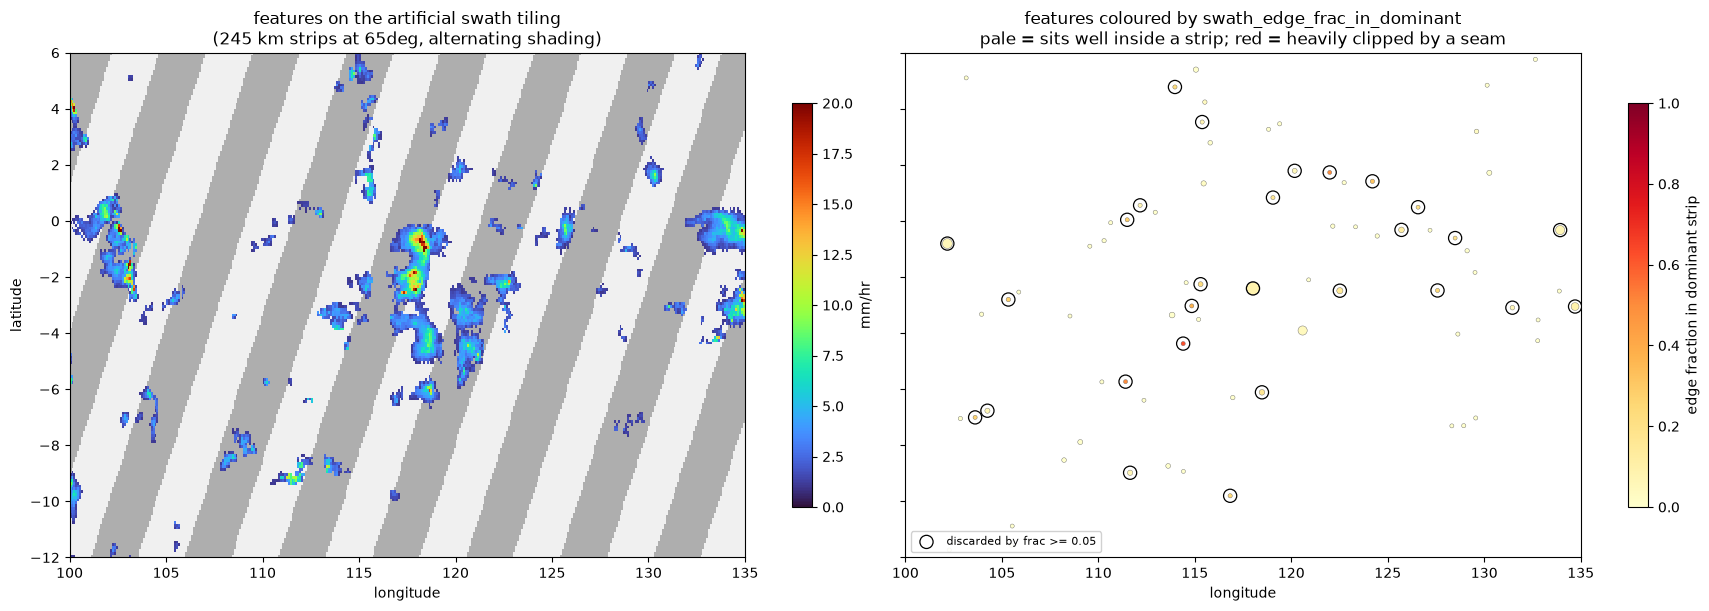

564/867 features (65.1%) pass the "mostly inside the swath" cut used in the DYAMOND comparison

median size of features kept     :     12 px
median size of features discarded:     25 px


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6), constrained_layout=True, sharey=True)

ax = axes[0]
ax.pcolormesh(win_lons, win_lats, swath[r0:r1, c0:c1] % 2, cmap='Greys',
              shading='nearest', vmin=-0.4, vmax=1.6, alpha=0.5)
masked = np.where(np.isnan(win_labels), np.nan, win_field)
im = ax.pcolormesh(win_lons, win_lats, masked, cmap='turbo', shading='nearest',
                   vmin=0, vmax=PRECIP_VMAX)
ax.set_title(f'features on the artificial swath tiling\n'
             f'({SWATH_WIDTH_KM:g} km strips at {SWATH_ANGLE_DEG:g}deg, alternating shading)')
fig.colorbar(im, ax=ax, shrink=0.8, label='mm/hr')

ax = axes[1]
CUT = 0.05
sc = ax.scatter(in_window.centroid_lon, in_window.centroid_lat,
                c=in_window.swath_edge_frac_in_dominant, s=8 + in_window.size_px / 12,
                cmap='YlOrRd', vmin=0, vmax=1, edgecolor='0.4', linewidth=0.3)
# Ring the features the DYAMOND-comparison cut would discard.
failed = in_window[in_window.swath_edge_frac_in_dominant >= CUT]
ax.scatter(failed.centroid_lon, failed.centroid_lat, s=90, facecolor='none',
           edgecolor='k', linewidth=0.9, label=f'discarded by frac >= {CUT}')
ax.legend(loc='lower left', fontsize=8, framealpha=0.9)
ax.set_title('features coloured by swath_edge_frac_in_dominant\n'
             'pale = sits well inside a strip; red = heavily clipped by a seam')
fig.colorbar(sc, ax=ax, shrink=0.8, label='edge fraction in dominant strip')

for ax in axes:
    ax.set_xlabel('longitude'); ax.set_xlim(PLOT_LON); ax.set_ylim(PLOT_LAT)
axes[0].set_ylabel('latitude')
plt.show()

kept = int((df.swath_edge_frac_in_dominant < 0.05).sum())
print(f'{kept}/{len(df)} features ({100*kept/len(df):.1f}%) pass the '
      f'"mostly inside the swath" cut used in the DYAMOND comparison\n')

k = df.swath_edge_frac_in_dominant < 0.05
print(f'median size of features kept     : {df.size_px[k].median():6.0f} px')
print(f'median size of features discarded: {df.size_px[~k].median():6.0f} px')

Note the size asymmetry in that last pair of numbers, visible as the ringed points in the
plot above: the cut preferentially removes **large** features, because a bigger feature is
more likely to run into a seam. That is the correct behaviour for emulating what a single
satellite overpass can observe — but it does mean the cut is not size-neutral, and the
same bias is imposed on the DYAMOND side by applying the identical cut there. Size
distributions compared across the two datasets are therefore like-for-like; size
distributions compared against an *unclipped* climatology would not be.

## 7. The parameters behave the way they are documented

A last check that the two knobs in the parameters cell do what their names say — that
raising the threshold shrinks and fragments features, and that `MIN_SIZE` only ever
removes small ones. If these were wired up wrongly, every number in the study would be
subtly off in a way no single-case check would reveal.

In [20]:
rows = []
for thr in (0.5, 1.0, 2.0, 5.0):
    for ms in (5, 20):
        d, _ = run_extraction(field, lats2d, lons2d, thr, ms, CONNECTIVITY)
        rows.append(dict(threshold=thr, min_size=ms, n_features=len(d),
                         total_px=int(d.size_px.sum()),
                         median_px=float(d.size_px.median()),
                         max_px=int(d.size_px.max())))
sweep = pd.DataFrame(rows)
sweep

,threshold,min_size,n_features,total_px,median_px,max_px
0,0.5,5,1145,100810,11.0,10649
1,0.5,20,410,94308,53.5,10649
2,1.0,5,867,64960,14.0,3116
3,1.0,20,344,59988,54.5,3116
4,2.0,5,616,35500,14.0,1514
5,2.0,20,253,32163,54.0,1514
6,5.0,5,297,10870,14.0,771
7,5.0,20,118,9231,36.5,771


In [21]:
piv = sweep.pivot(index='threshold', columns='min_size', values='total_px')
mono_px = bool((piv.diff().dropna() <= 0).all().all())
sub5, sub20 = sweep[sweep.min_size == 5], sweep[sweep.min_size == 20]

sweep_checks = [
    ('raising the threshold never increases total feature area', mono_px),
    ('raising min_size never increases feature count',
        bool((sub20.n_features.values <= sub5.n_features.values).all())),
    ('raising min_size never changes the largest feature',
        bool((sub20.max_px.values == sub5.max_px.values).all())),
    ('min_size only ever removes small features',
        bool((sub20.median_px.values >= sub5.median_px.values).all())),
]
for name, ok in sweep_checks:
    print(f"  {'PASS' if ok else 'FAIL':4s}  {name}")
assert all(ok for _, ok in sweep_checks)

  PASS  raising the threshold never increases total feature area
  PASS  raising min_size never increases feature count
  PASS  raising min_size never changes the largest feature
  PASS  min_size only ever removes small features


## 8. Summary

In [22]:
all_checks = (checks + syn_checks + conn_checks + part_checks
              + stat_checks + swath_checks + sweep_checks)
n_pass = sum(1 for _, ok in all_checks if ok)

print(f'{n_pass}/{len(all_checks)} checks passed on {len(df)} real features '
      f'at {tlabel}\n')
for name, ok in all_checks:
    print(f"  {'PASS' if ok else 'FAIL':4s}  {name}")

assert n_pass == len(all_checks), 'SOME CHECKS FAILED'
print('\n' + '=' * 64)
print('ALL CHECKS PASSED')
print('=' * 64)

46/46 checks passed on 867 real features at 2022-02-15T18:00:00

  PASS  fill sentinel is gone from the field
  PASS  fill became NaN (25 px), not a number
  PASS  fill did NOT become valid weak precip
  PASS  feature D (3 px) dropped by MIN_SIZE=5
  PASS  exactly 3 features survive
  PASS  A size == 20 px as drawn
  PASS  A mean == 2.0 mm/hr exactly
  PASS  A max  == 2.0 mm/hr exactly
  PASS  B size == 9 px as drawn
  PASS  B core >=10 mm/hr == 2 px
  PASS  B has exactly 1 contiguous hi core
  PASS  C corner-touching merged (8-conn)
  PASS  no feature overlaps the NaN block
  PASS  8-conn merges the corner touch into 18 px
  PASS  4-conn splits it into two 9 px features
  PASS  same number of features
  PASS  identical pixel partition
  PASS  no feature smaller than MIN_SIZE
  PASS  no NaN pixel inside any feature
  PASS  size_px matches independent recomputation
  PASS  area_km2 matches independent recomputation
  PASS  max_precip_mm_hr matches independent recomputation
  PASS  mean_

### What this does and does not establish

It establishes that the pipeline computes what it claims: the partition into features is
reproducible by an independent implementation, every statistic in the CSV can be re-derived
from the raw field, the fill value never masquerades as precipitation, and the swath
columns are internally consistent.

It does not establish that IMERG itself is accurate, nor that the threshold and minimum
size are the *right* scientific choices — those are judgement calls about what counts as a
precipitation feature. What the notebook does let you do is change them in the parameters
cell and see the consequences immediately.